# Overview Fantasy Football View 2025

## Preparations

#### Laden der Pakete

In [1]:
import Package_NFLCOM_Scoring as Scoring
import Package_utils as utils
import nflreadpy as nfl
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

### Datengrundlage

##### Datenbasis ziehen 

In [2]:
df_kicker = Scoring.get_kicker_scorings().filter(pl.col('season_type')=='REG')
df_offense = Scoring.get_offensive_scorings()
df_defense = Scoring.get_defense_scorings()

## Offense Rangliste nach Position 

### Kicker

In [3]:
# @k: Top k Kicker werden betrachtet 
k=10

In [4]:
kicker_top_k = (
    df_kicker
    .filter(pl.col('season_type') == "REG")
    .group_by('player_display_name')
    .agg(
        pl.col("fg_made_close").sum(),
        pl.col("fg_made_far").sum(),
        pl.col("ff_missed_points").sum(),
        pl.col("ff_total_points").sum(),
    )
    .sort('ff_total_points', descending=True)
 )[:k, :]

kicker_top_k = kicker_top_k.join(
    other=df_kicker,
    how='inner',
    on='player_display_name',
    suffix='_game'
)

Kumulierte Punkte der k besten Kicker im Verlauf der REG

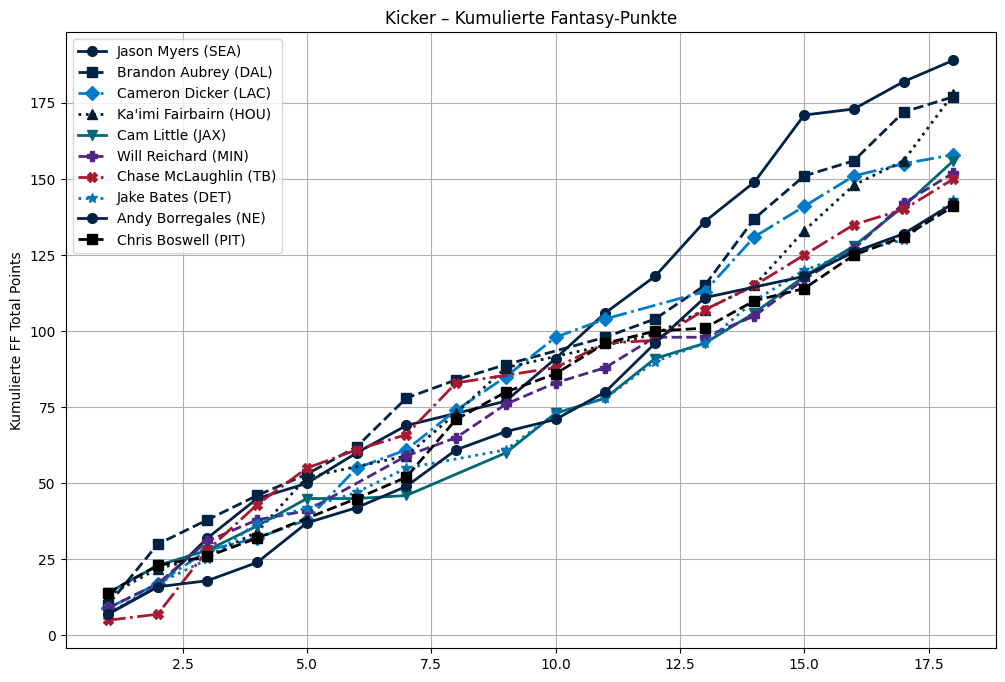

In [5]:
# 1. Kumulierte Punkte berechnen
df_cum = (
    kicker_top_k
    .sort(["player_display_name", "week"])
    .with_columns(
        pl.col("ff_total_points_game")
        .cum_sum()
        .over("player_display_name")
        .alias("cum_points")
    )
)

# 2. Sortierung nach Gesamtpunkten
df_totals = (
    kicker_top_k
    .group_by("player_display_name")
    .agg(pl.col("ff_total_points").sum().alias("total_points"))
    .sort("total_points", descending=True)
)
df_rank = (
    kicker_top_k
    .sort(["week", "ff_total_points_game"], descending=[False, True])
    .with_columns(
        pl.col("ff_total_points_game")
        .rank("dense", descending=True)
        .over("week")
        .alias("rank")
    )
)

pdf_rank = df_rank.to_pandas()
sorted_names = df_totals["player_display_name"].to_list()

# 3. Für Matplotlib in Pandas umwandeln
pdf = df_cum.to_pandas()

fig, axs = plt.subplots(figsize=[12,8])
team_color_map = utils.get_team_color_map()
markers = ["o", "s", "D", "^", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

handles = []
labels = []

for i, name in enumerate(sorted_names):
    group = pdf[pdf["player_display_name"] == name]
    team = group["team"].iloc[0]

    color = team_color_map.get(team, "black")
    marker = markers[i % len(markers)]
    linestyle = linestyles[i % len(linestyles)]

    line, = plt.plot(
        group["week"],
        group["cum_points"],
        marker=marker,
        linestyle=linestyle,
        color=color,
        linewidth=2,
        markersize=7,
    )

    handles.append(line)
    labels.append(f"{name} ({team})")

axs.set_ylabel("Kumulierte FF Total Points")
axs.set_title("Kicker – Kumulierte Fantasy-Punkte")
axs.legend(handles, labels, loc="upper left")
axs.grid(True)

plt.show()

### Quarterback (QB)

In [6]:
#@k: Analysiere die besten k Quarterbacks
k=10
df_qb = (
    df_offense
    .filter((pl.col('position_group')=='QB') & (pl.col('season_type') == "REG"))
    .select([
        'player_display_name', 'player_id',
        'game_id', 'team', 'opponent_team',	'week',
        'rushing_tds', 'rushing_fumbles_lost', 'rushing_2pt_conversions', 'ff_rushing_points',
        'passing_yards', 'passing_tds', 'passing_interceptions', 'passing_2pt_conversions',
        'sack_fumbles_lost', 'ff_passing_points', 'ff_total_points'
    ])
    .join(
        other=nfl.load_players()['gsis_id', 'pfr_id'],
        how='left',
        left_on='player_id',
        right_on='gsis_id'
    )
)

df_qb = (
    df_qb
    .join(
        other=nfl.load_snap_counts(2025)['game_id', 'pfr_player_id', 'offense_snaps', 'offense_pct'],
        how='left',
        left_on=['pfr_id', 'game_id'],
        right_on=['pfr_player_id', 'game_id']
    )
)

qb_season_points = (
    df_qb
    .group_by('player_display_name')
    .agg(
        pl.col("ff_passing_points").sum(),
        pl.col("ff_rushing_points").sum(),
        pl.col("ff_total_points").sum(),
    )
    .sort('ff_total_points', descending=True)
 )

df_qb = df_qb.join(
    other=qb_season_points,
    how='inner',
    on='player_display_name',
    suffix='_season'
).sort('ff_total_points_season', descending=True)

df_qb = (
    df_qb
    .sort(["week", "ff_total_points"], descending=[False, True])
    .with_columns(
        pl.col("ff_total_points")
        .rank("dense", descending=True)
        .over("week")
        .alias("rank")
    )
)

top_k_player = (
    df_qb
    .select([
        'player_id', 'ff_total_points_season'
    ])
    .unique()
    .sort('ff_total_points_season', descending=True)
    .head(n=k)
    .select(['player_id'])
)

df_qb =(
    df_qb
    .join(
        other=top_k_player,
        how='inner',
        on='player_id'
    )
    .sort(['ff_total_points_season', 'week'], descending=[True, False])
)

/tmp/ipykernel_1316/1547807590.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=22.5, ha="right")
/tmp/ipykernel_1316/1547807590.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=22.5, ha="right")


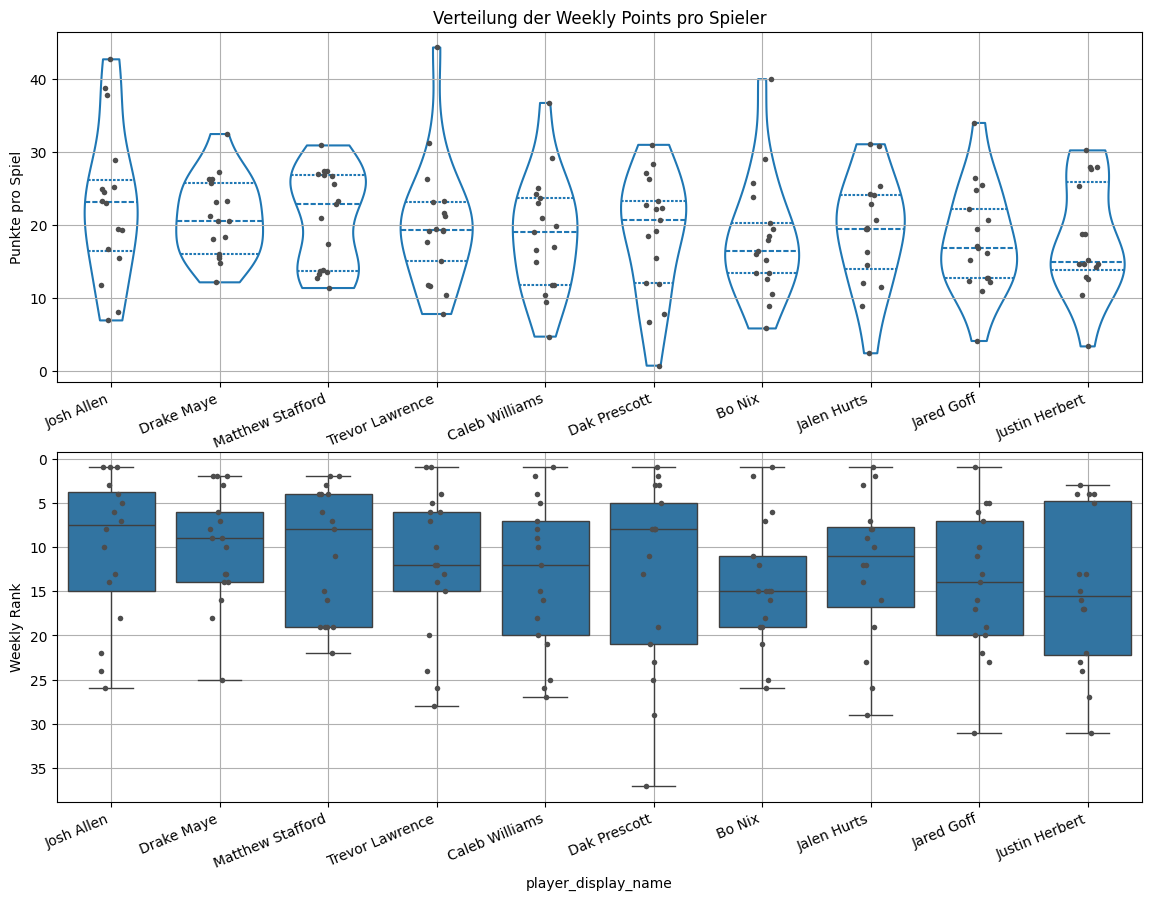

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(14, 10))

sns.violinplot(
    ax=axs[0],
    data=df_qb,
    x="player_display_name",
    y="ff_total_points",
    inner="quartile",
    fill=False,
    cut=0
)
# Add in points to show each observation
sns.stripplot(
    ax=axs[0],
    data=df_qb,
    x="player_display_name",
    y="ff_total_points",
    size=4, 
    color=".3"
)
axs[0].grid()
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=22.5, ha="right")
axs[0].set_ylabel("Punkte pro Spiel")
axs[0].set_title("Verteilung der Weekly Points pro Spieler")

sns.boxplot(
    ax=axs[1],
    data=df_qb,
    x="player_display_name",
    y="rank",
    orient='x'
)
sns.stripplot(
    ax=axs[1],
    data=df_qb,
    x="player_display_name",
    y="rank",
    size=4, 
    color=".3"
)
axs[1].grid()
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=22.5, ha="right")
axs[1].invert_yaxis()
axs[1].set_ylabel("Weekly Rank")
plt.show()


### Running Back (RB)

In [8]:
#@k: Analysiere die besten k Quarterbacks
k=10
df_rb = (
    df_offense
    .filter((pl.col('position_group')=='RB') & (pl.col('season_type') == "REG"))
    .select([
        'player_display_name', 'player_id',
        'game_id', 'team', 'opponent_team',	'week',
        'rushing_tds', 'rushing_fumbles_lost', 'rushing_2pt_conversions', 'ff_rushing_points',
            'receiving_yards', 'receiving_2pt_conversions', 'receptions', 'receiving_fumbles_lost', 'ff_receiving_points', 'ff_total_points'
    ])
    .join(
        other=nfl.load_players()['gsis_id', 'pfr_id'],
        how='left',
        left_on='player_id',
        right_on='gsis_id'
    )
)

df_rb = (
    df_rb
    .join(
        other=nfl.load_snap_counts(2025)['game_id', 'pfr_player_id', 'offense_snaps', 'offense_pct'],
        how='left',
        left_on=['pfr_id', 'game_id'],
        right_on=['pfr_player_id', 'game_id']
    )
)

rb_season_points = (
    df_rb
    .group_by('player_display_name')
    .agg(
        pl.col("ff_receiving_points").sum(),
        pl.col("ff_rushing_points").sum(),
        pl.col("ff_total_points").sum(),
    )
    .sort('ff_total_points', descending=True)
 )

df_rb = df_rb.join(
    other=rb_season_points,
    how='inner',
    on='player_display_name',
    suffix='_season'
).sort('ff_total_points_season', descending=True)

df_rb = (
    df_rb
    .sort(["week", "ff_total_points"], descending=[False, True])
    .with_columns(
        pl.col("ff_total_points")
        .rank("dense", descending=True)
        .over("week")
        .alias("rank")
    )
)

top_k_player = (
    df_rb
    .select([
        'player_id', 'ff_total_points_season'
    ])
    .unique()
    .sort('ff_total_points_season', descending=True)
    .head(n=k)
    .select(['player_id'])
)

df_rb =(
    df_rb
    .join(
        other=top_k_player,
        how='inner',
        on='player_id'
    )
    .sort(['ff_total_points_season', 'week'], descending=[True, False])
)

/tmp/ipykernel_1316/4087069045.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=22.5, ha="right")
/tmp/ipykernel_1316/4087069045.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=22.5, ha="right")


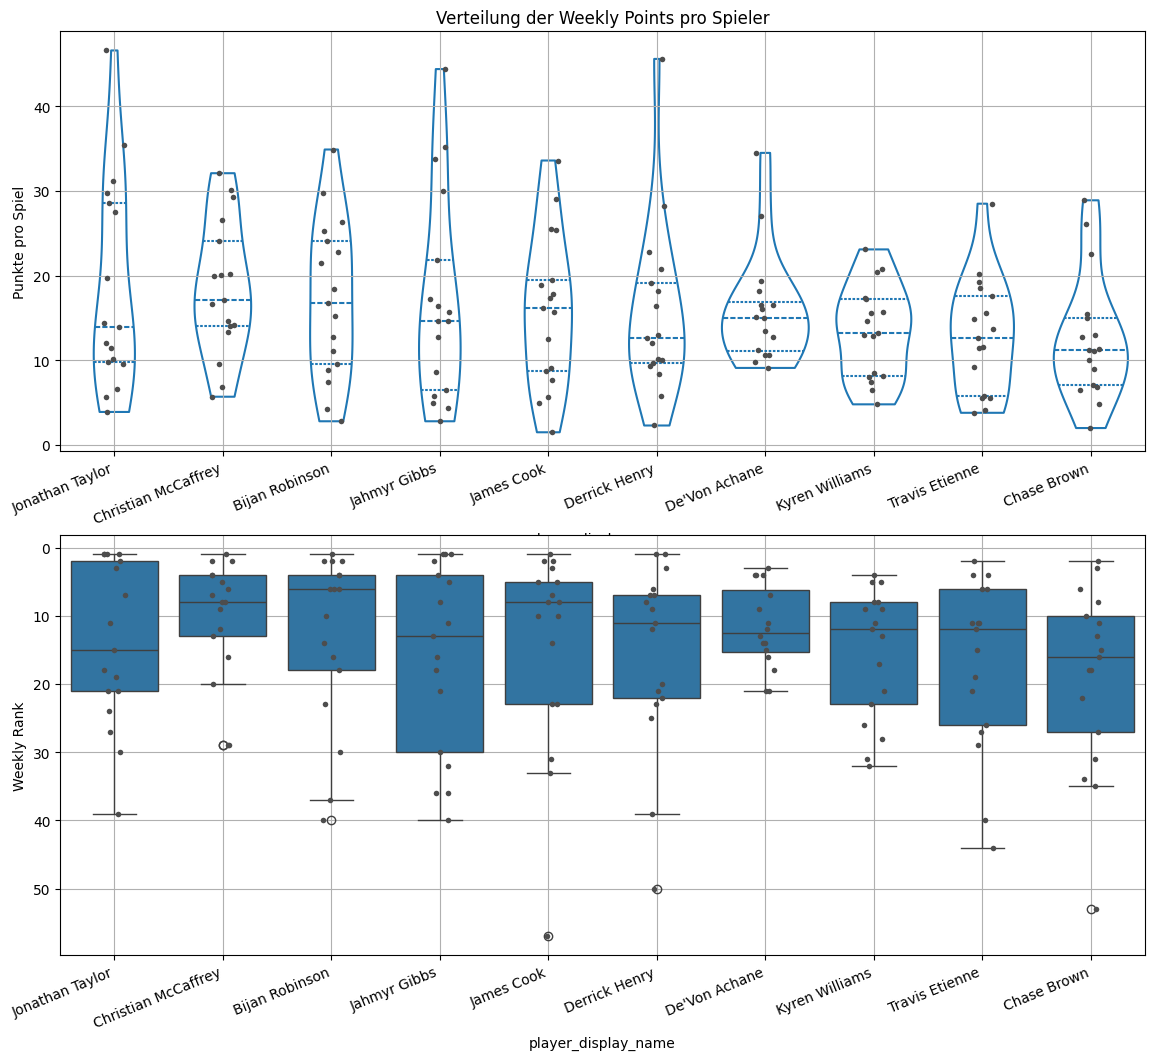

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(14, 12))

sns.violinplot(
    ax=axs[0],
    data=df_rb,
    x="player_display_name",
    y="ff_total_points",
    inner="quartile",
    fill=False,
    cut=0
)
# Add in points to show each observation
sns.stripplot(
    ax=axs[0],
    data=df_rb,
    x="player_display_name",
    y="ff_total_points",
    size=4, 
    color=".3"
)
axs[0].grid()
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=22.5, ha="right")
axs[0].set_ylabel("Punkte pro Spiel")
axs[0].set_title("Verteilung der Weekly Points pro Spieler")

sns.boxplot(
    ax=axs[1],
    data=df_rb,
    x="player_display_name",
    y="rank",
    orient='x'
)
sns.stripplot(
    ax=axs[1],
    data=df_rb,
    x="player_display_name",
    y="rank",
    size=4, 
    color=".3"
)
axs[1].grid()
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=22.5, ha="right")
axs[1].invert_yaxis()
axs[1].set_ylabel("Weekly Rank")
plt.show()


### Wide Receiver (WR)

In [10]:
#@k: Analysiere die besten k Quarterbacks
k=10
df_wr = (
    df_offense
    .filter((pl.col('position_group')=='WR') & (pl.col('season_type') == "REG"))
    .select([
        'player_display_name', 'player_id',
        'game_id', 'team', 'opponent_team',	'week',
        'rushing_tds', 'rushing_fumbles_lost', 'rushing_2pt_conversions', 'ff_rushing_points',
            'receiving_yards', 'receiving_2pt_conversions', 'receptions', 'receiving_fumbles_lost', 'ff_receiving_points', 'ff_total_points'
    ])
    .join(
        other=nfl.load_players()['gsis_id', 'pfr_id'],
        how='left',
        left_on='player_id',
        right_on='gsis_id'
    )
)

df_wr = (
    df_wr
    .join(
        other=nfl.load_snap_counts(2025)['game_id', 'pfr_player_id', 'offense_snaps', 'offense_pct'],
        how='left',
        left_on=['pfr_id', 'game_id'],
        right_on=['pfr_player_id', 'game_id']
    )
)

wr_season_points = (
    df_wr
    .group_by('player_display_name')
    .agg(
        pl.col("ff_receiving_points").sum(),
        pl.col("ff_rushing_points").sum(),
        pl.col("ff_total_points").sum(),
    )
    .sort('ff_total_points', descending=True)
 )

df_wr = df_wr.join(
    other=wr_season_points,
    how='inner',
    on='player_display_name',
    suffix='_season'
).sort('ff_total_points_season', descending=True)

df_wr = (
    df_wr
    .sort(["week", "ff_total_points"], descending=[False, True])
    .with_columns(
        pl.col("ff_total_points")
        .rank("dense", descending=True)
        .over("week")
        .alias("rank")
    )
)

top_k_player = (
    df_wr
    .select([
        'player_id', 'ff_total_points_season'
    ])
    .unique()
    .sort('ff_total_points_season', descending=True)
    .head(n=k)
    .select(['player_id'])
)

df_wr =(
    df_wr
    .join(
        other=top_k_player,
        how='inner',
        on='player_id'
    )
    .sort(['ff_total_points_season', 'week'], descending=[True, False])
)

/tmp/ipykernel_1316/4036520700.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=22.5, ha="right")
/tmp/ipykernel_1316/4036520700.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=22.5, ha="right")


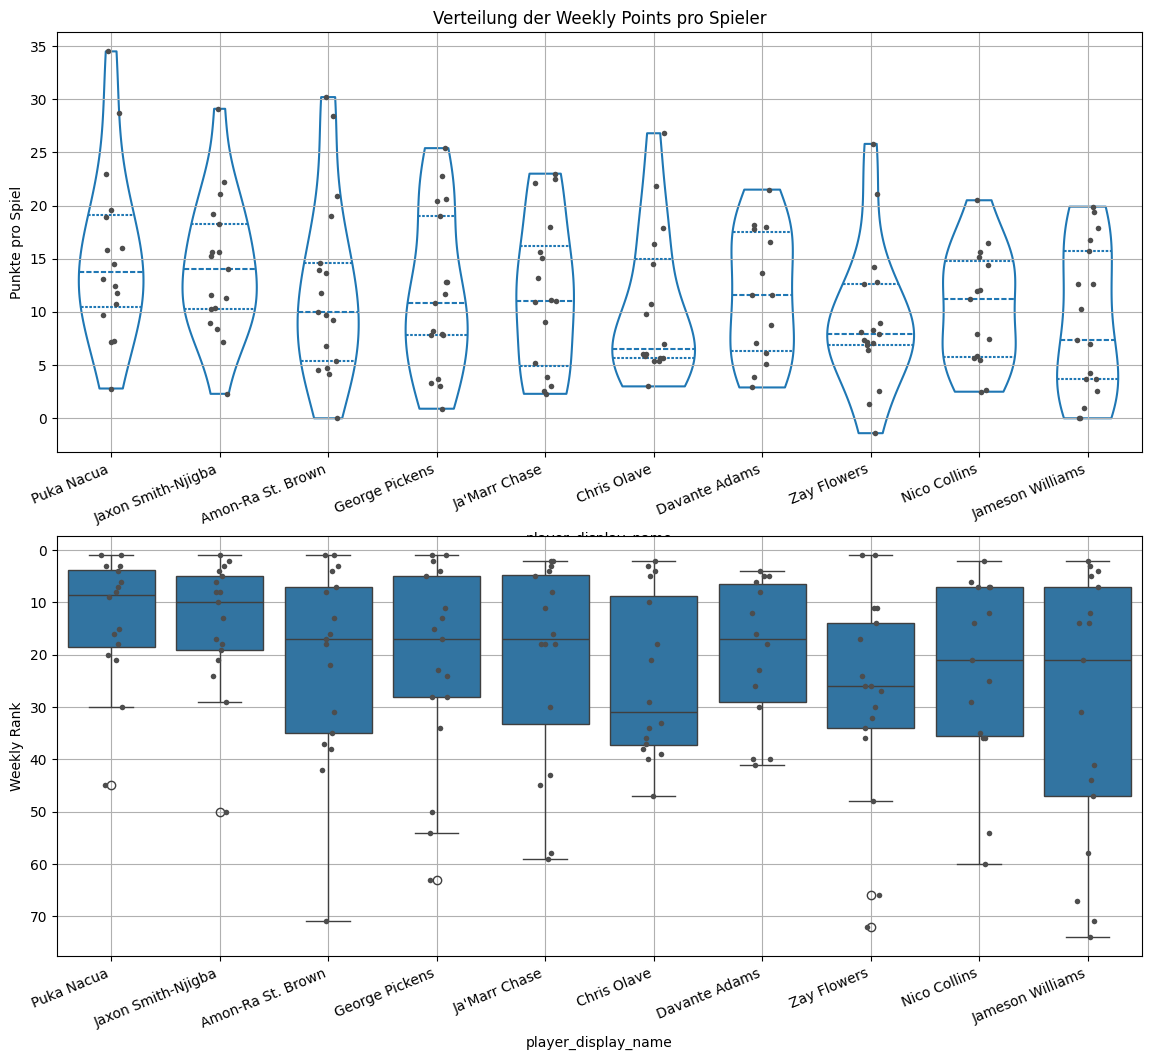

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(14, 12))

sns.violinplot(
    ax=axs[0],
    data=df_wr,
    x="player_display_name",
    y="ff_total_points",
    inner="quartile",
    fill=False,
    cut=0
)
# Add in points to show each observation
sns.stripplot(
    ax=axs[0],
    data=df_wr,
    x="player_display_name",
    y="ff_total_points",
    size=4, 
    color=".3"
)
axs[0].grid()
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=22.5, ha="right")
axs[0].set_ylabel("Punkte pro Spiel")
axs[0].set_title("Verteilung der Weekly Points pro Spieler")

sns.boxplot(
    ax=axs[1],
    data=df_wr,
    x="player_display_name",
    y="rank",
    orient='x'
)
sns.stripplot(
    ax=axs[1],
    data=df_wr,
    x="player_display_name",
    y="rank",
    size=4, 
    color=".3"
)
axs[1].grid()
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=22.5, ha="right")
axs[1].invert_yaxis()
axs[1].set_ylabel("Weekly Rank")
plt.show()


### Tide End (TE)

In [12]:
#@k: Analysiere die besten k Tide Ends
k=10
df_te = (
    df_offense
    .filter((pl.col('position_group')=='TE') & (pl.col('season_type') == "REG"))
    .select([
        'player_display_name', 'player_id',
        'game_id', 'team', 'opponent_team',	'week',
        'rushing_tds', 'rushing_fumbles_lost', 'rushing_2pt_conversions', 'ff_rushing_points',
        'receiving_tds', 'receiving_yards', 'receiving_2pt_conversions', 'receptions', 'receiving_fumbles_lost', 'ff_receiving_points', 'ff_total_points'
    ])
    .join(
        other=nfl.load_players()['gsis_id', 'pfr_id'],
        how='left',
        left_on='player_id',
        right_on='gsis_id'
    )
)

df_te = (
    df_te
    .join(
        other=nfl.load_snap_counts(2025)['game_id', 'pfr_player_id', 'offense_snaps', 'offense_pct'],
        how='left',
        left_on=['pfr_id', 'game_id'],
        right_on=['pfr_player_id', 'game_id']
    )
)

wr_season_points = (
    df_te
    .group_by('player_display_name')
    .agg(
        pl.col("ff_receiving_points").sum(),
        pl.col("ff_rushing_points").sum(),
        pl.col("ff_total_points").sum(),
    )
    .sort('ff_total_points', descending=True)
 )

df_te = df_te.join(
    other=wr_season_points,
    how='inner',
    on='player_display_name',
    suffix='_season'
).sort('ff_total_points_season', descending=True)

df_te = (
    df_te
    .sort(["week", "ff_total_points"], descending=[False, True])
    .with_columns(
        pl.col("ff_total_points")
        .rank("dense", descending=True)
        .over("week")
        .alias("rank")
    )
)

top_k_player = (
    df_te
    .select([
        'player_id', 'ff_total_points_season'
    ])
    .unique()
    .sort('ff_total_points_season', descending=True)
    .head(n=k)
    .select(['player_id'])
)

df_te =(
    df_te
    .join(
        other=top_k_player,
        how='inner',
        on='player_id'
    )
    .sort(['ff_total_points_season', 'week'], descending=[True, False])
)

/tmp/ipykernel_1316/893812811.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=22.5, ha="right")
/tmp/ipykernel_1316/893812811.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=22.5, ha="right")


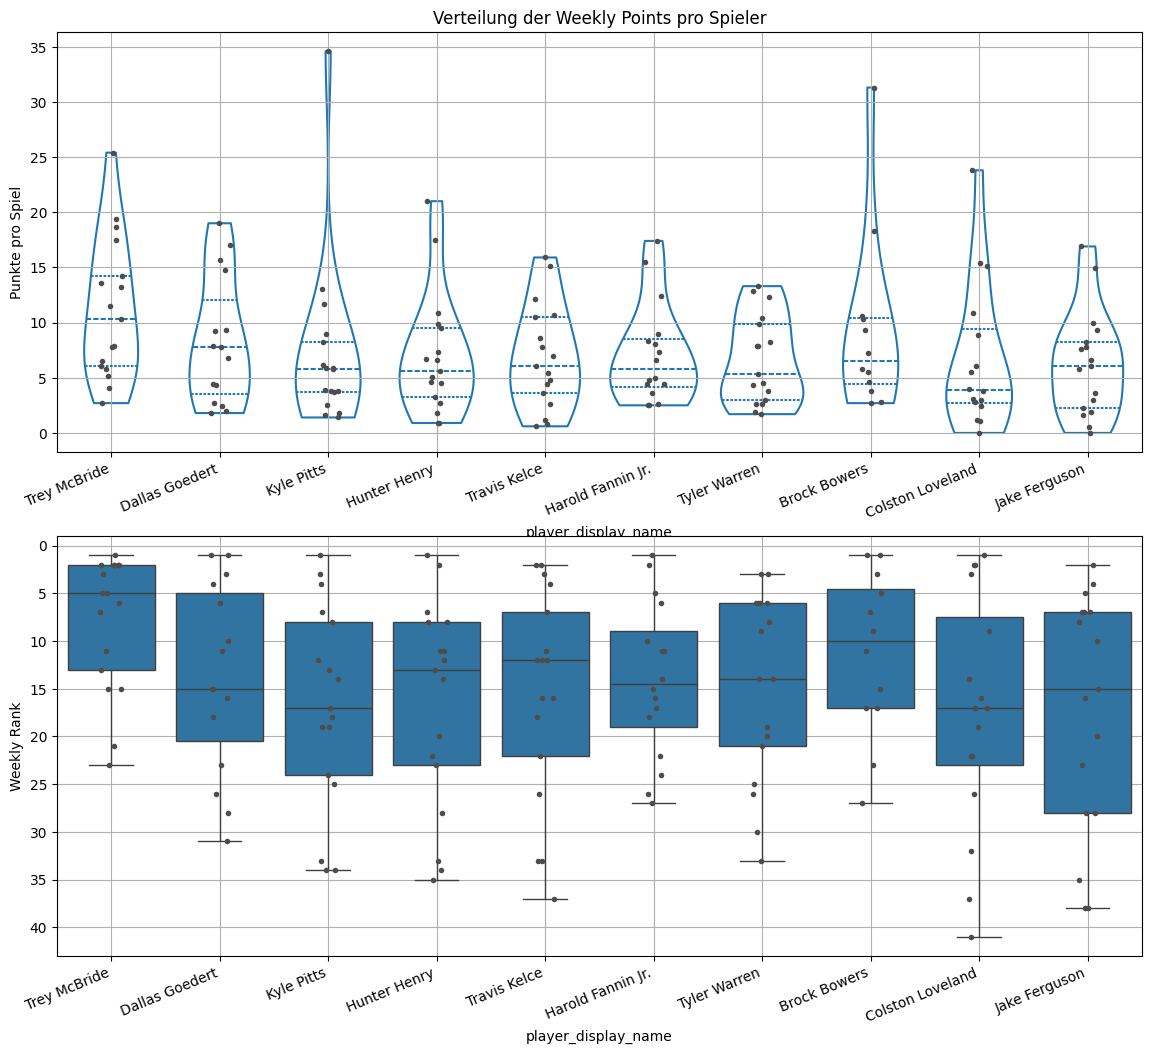

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(14, 12))

sns.violinplot(
    ax=axs[0],
    data=df_te,
    x="player_display_name",
    y="ff_total_points",
    inner="quartile",
    fill=False,
    cut=0
)
# Add in points to show each observation
sns.stripplot(
    ax=axs[0],
    data=df_te,
    x="player_display_name",
    y="ff_total_points",
    size=4, 
    color=".3"
)
axs[0].grid()
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=22.5, ha="right")
axs[0].set_ylabel("Punkte pro Spiel")
axs[0].set_title("Verteilung der Weekly Points pro Spieler")

sns.boxplot(
    ax=axs[1],
    data=df_te,
    x="player_display_name",
    y="rank",
    orient='x'
)
sns.stripplot(
    ax=axs[1],
    data=df_te,
    x="player_display_name",
    y="rank",
    size=4, 
    color=".3"
)
axs[1].grid()
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=22.5, ha="right")
axs[1].invert_yaxis()
axs[1].set_ylabel("Weekly Rank")
plt.show()


## Defense

In [14]:
#@k: Analysiere die besten k Quarterbacks
k=10



df_wr = df_wr.join(
    other=wr_season_points,
    how='inner',
    on='player_display_name',
    suffix='_season'
).sort('ff_total_points_season', descending=True)

df_wr = (
    df_wr
    .sort(["week", "ff_total_points"], descending=[False, True])
    .with_columns(
        pl.col("ff_total_points")
        .rank("dense", descending=True)
        .over("week")
        .alias("rank")
    )
)

top_k_player = (
    df_wr
    .select([
        'player_id', 'ff_total_points_season'
    ])
    .unique()
    .sort('ff_total_points_season', descending=True)
    .head(n=k)
    .select(['player_id'])
)

df_wr =(
    df_wr
    .join(
        other=top_k_player,
        how='inner',
        on='player_id'
    )
    .sort(['ff_total_points_season', 'week'], descending=[True, False])
)

DuplicateError: column with name 'ff_receiving_points_season' already exists

You may want to try:
- renaming the column prior to joining
- using the `suffix` parameter to specify a suffix different to the default one ('_right')

Text(0.5, 1.0, 'Verteilung der Weekly Points pro Spieler')

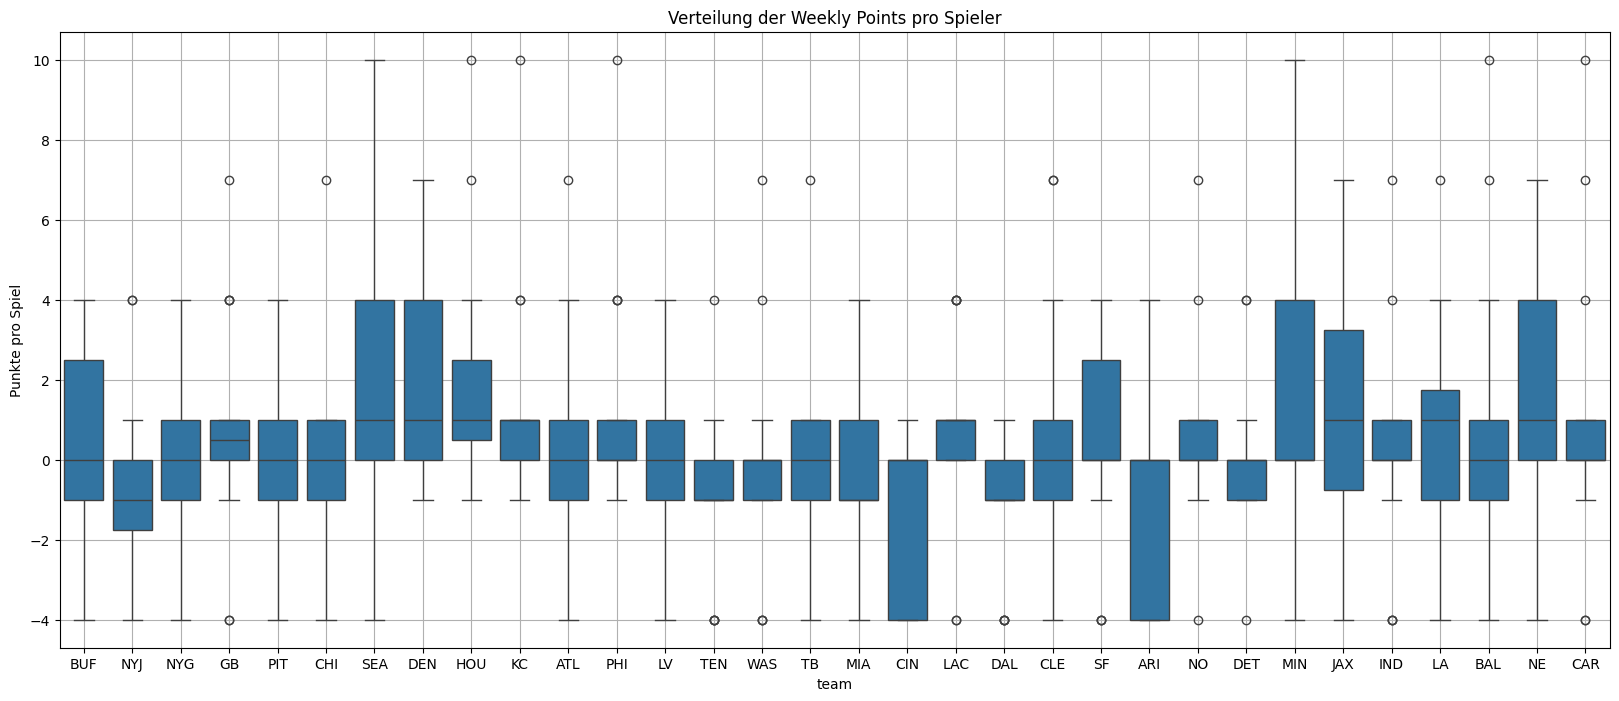

In [ ]:
plt.figure(figsize=(20, 8))

sns.boxplot(
    data=df_defense,
    x="team",
    y="ff_def_total_points"
)
plt.grid()
plt.ylabel("Punkte pro Spiel")
plt.title("Verteilung der Weekly Points pro Spieler")

